In [2]:
# Import the libraries required for data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Create a folder to save the generated visualizations
output_dir = Path("visualizations")
output_dir.mkdir(exist_ok=True)

# Apply a consistent style to all charts
sns.set_theme(style="whitegrid")

# Display all columns when inspecting the dataset
pd.set_option("display.max_columns", None)

In [3]:
# Load the Netflix dataset
df = pd.read_csv("raw/netflix_titles.csv")

# Display the first five records
display(df.head())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
# Find the dimensions of the dataset
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 8807
Number of columns: 12


In [5]:
# Inspect column names and data types
print(df.dtypes)

# Display detailed information about the dataset
df.info()

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1

In [6]:
# Summarize numerical columns
display(df.describe())

# Summarize categorical columns
display(df.describe(include="object"))

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


In [7]:
# Count missing values in each column
missing_values = df.isnull().sum()

# Calculate the percentage of missing values
missing_percentage = (missing_values / len(df)) * 100

# Combine the results into a table
missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage.round(2)
})

display(missing_summary)

,Missing Values,Missing Percentage
show_id,0,0.00
type,0,0.00
title,0,0.00
director,2634,29.91
cast,825,9.37
country,831,9.44
date_added,10,0.11
release_year,0,0.00
rating,4,0.05
duration,3,0.03


In [8]:
# Keep the original DataFrame unchanged
data = df.copy()

# Convert date_added into a proper date format
data["date_added"] = pd.to_datetime(
    data["date_added"].astype("string").str.strip(),
    format="%B %d, %Y",
    errors="coerce"
)

# Extract the year in which a title was added to Netflix
data["year_added"] = data["date_added"].dt.year

# Clean whitespace from important categorical columns
for column in ["type", "country", "rating", "listed_in"]:
    data[column] = data[column].astype("string").str.strip()

# Create a movie-only dataset for duration analysis
movies = data[data["type"] == "Movie"].copy()

# Extract movie duration in minutes
movies["duration_minutes"] = pd.to_numeric(
    movies["duration"].str.extract(r"(\d+)")[0],
    errors="coerce"
)

# Extract the number of seasons for TV shows
tv_shows = data[data["type"] == "TV Show"].copy()

tv_shows["seasons"] = pd.to_numeric(
    tv_shows["duration"].str.extract(r"(\d+)")[0],
    errors="coerce"
)

print("Data preparation completed.")

Data preparation completed.


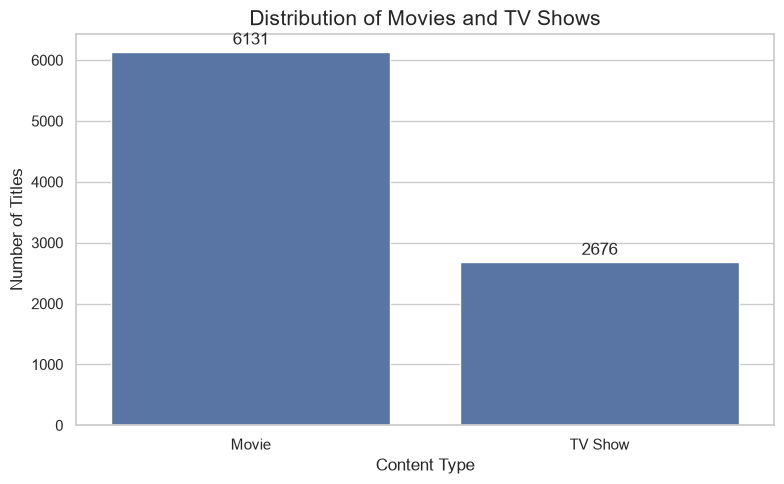

In [9]:
# Count the number of titles in each category
content_counts = data["type"].value_counts()

# Create the chart
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=content_counts.index,
    y=content_counts.values
)

# Add titles and labels
plt.title("Distribution of Movies and TV Shows", fontsize=15)
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

# Display the count above each bar
ax.bar_label(ax.containers[0], fmt="%.0f", padding=3)

plt.tight_layout()

# Save the chart for the Word report
plt.savefig(
    output_dir / "01_content_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

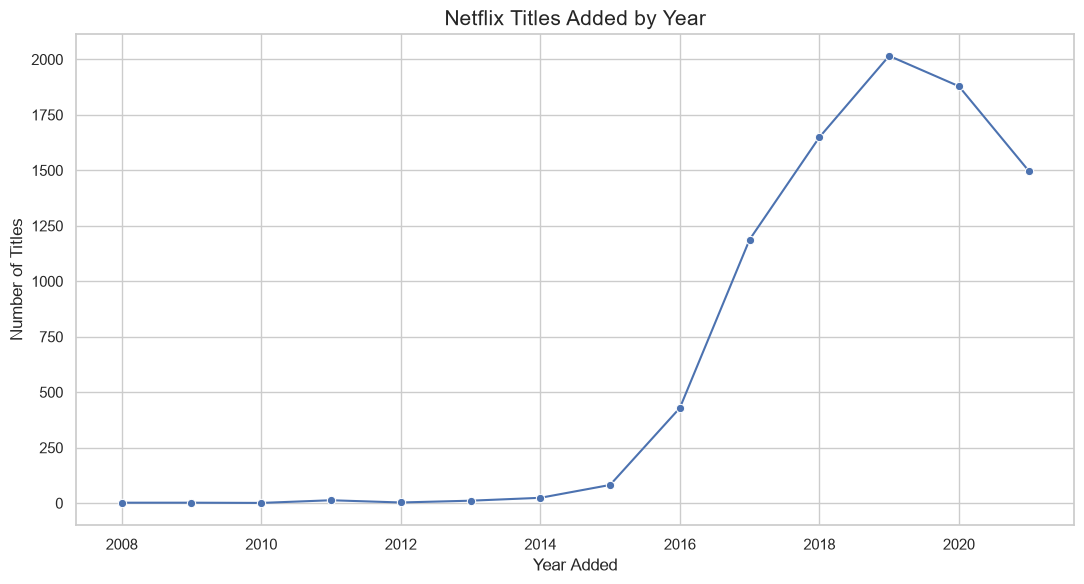

In [10]:
# Count titles added in each year
yearly_additions = (
    data.dropna(subset=["year_added"])
        .groupby("year_added")
        .size()
        .sort_index()
)

# Create the line chart
plt.figure(figsize=(11, 6))

sns.lineplot(
    x=yearly_additions.index,
    y=yearly_additions.values,
    marker="o"
)

plt.title("Netflix Titles Added by Year", fontsize=15)
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")

plt.tight_layout()

plt.savefig(
    output_dir / "02_content_added_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

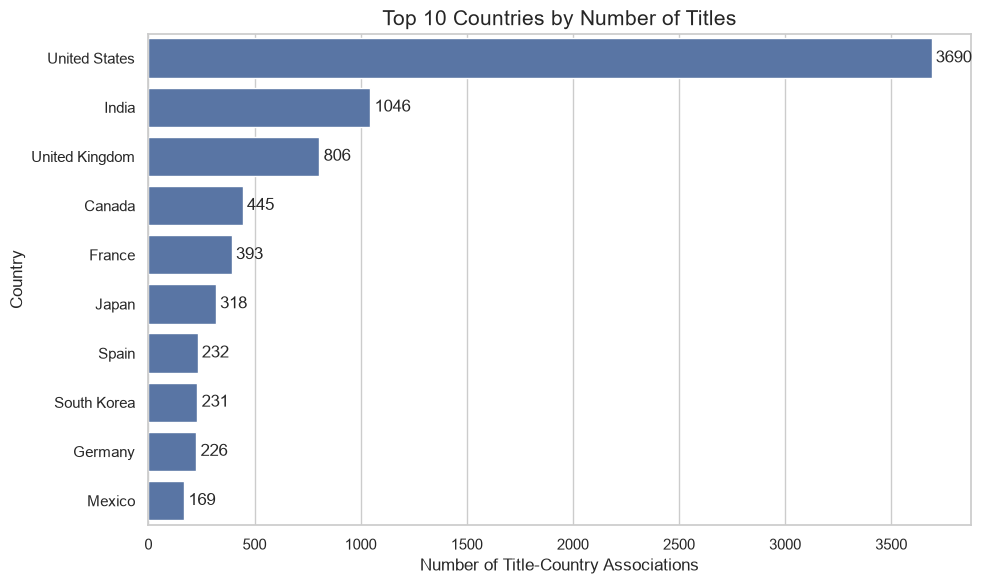

In [11]:
# Remove records with missing country information
country_data = data.dropna(subset=["country"]).copy()

# Split titles with multiple countries into separate entries
country_data["country"] = country_data["country"].str.split(",")

country_data = country_data.explode("country")

# Remove extra whitespace
country_data["country"] = country_data["country"].str.strip()

# Count titles associated with each country
country_counts = country_data["country"].value_counts().head(10)

# Create the horizontal bar chart
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

plt.title("Top 10 Countries by Number of Titles", fontsize=15)
plt.xlabel("Number of Title-Country Associations")
plt.ylabel("Country")

ax.bar_label(ax.containers[0], fmt="%.0f", padding=3)

plt.tight_layout()

plt.savefig(
    output_dir / "03_top_countries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

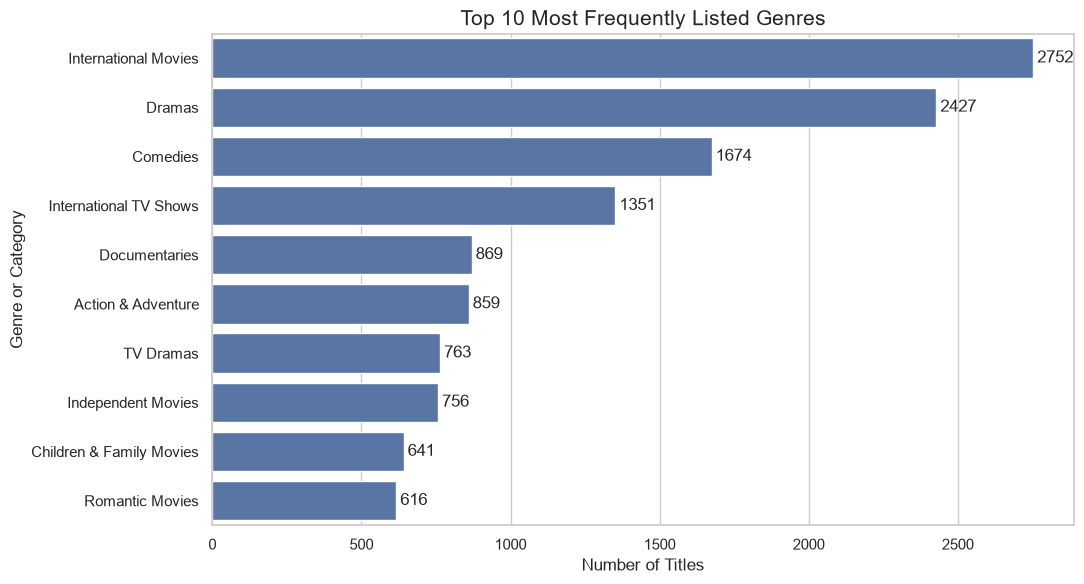

In [12]:
# Select records that contain genre information
genre_data = data.dropna(subset=["listed_in"]).copy()

# Split titles containing multiple genres
genre_data["listed_in"] = genre_data["listed_in"].str.split(",")

# Put each genre on a separate row
genre_data = genre_data.explode("listed_in")

# Remove unnecessary whitespace
genre_data["listed_in"] = genre_data["listed_in"].str.strip()

# Count the 10 most frequently listed categories
genre_counts = genre_data["listed_in"].value_counts().head(10)

# Create the chart
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index
)

plt.title("Top 10 Most Frequently Listed Genres", fontsize=15)
plt.xlabel("Number of Titles")
plt.ylabel("Genre or Category")

ax.bar_label(ax.containers[0], fmt="%.0f", padding=3)

plt.tight_layout()

plt.savefig(
    output_dir / "04_top_genres.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

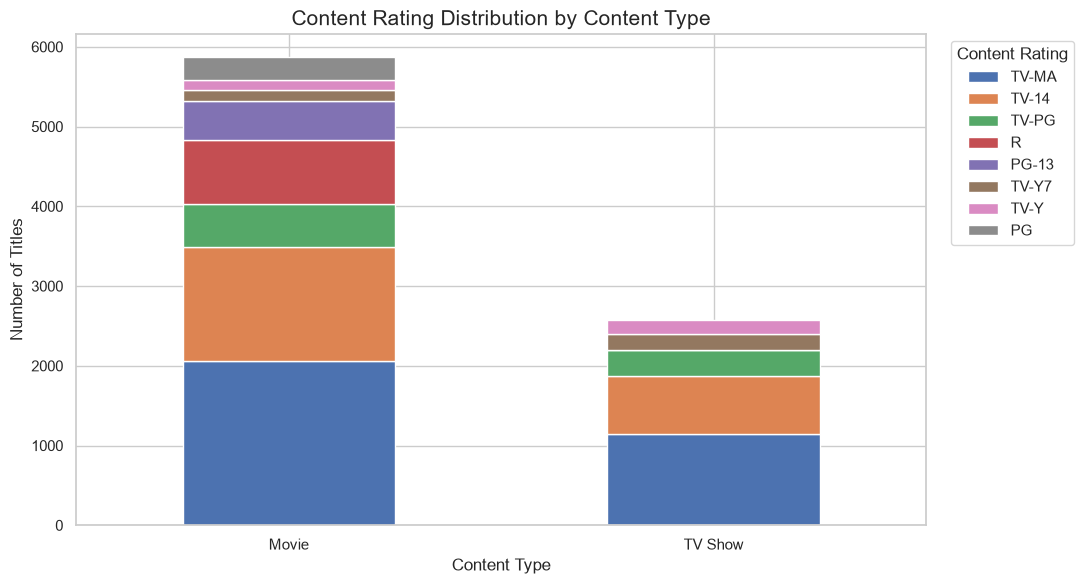

In [13]:
# Select records with known content type and rating
rating_data = data.dropna(subset=["type", "rating"]).copy()

# Create a table showing counts for each type-rating combination
rating_counts = pd.crosstab(
    rating_data["type"],
    rating_data["rating"]
)

# Keep the most frequent rating categories overall
top_ratings = rating_data["rating"].value_counts().head(8).index

rating_counts = rating_counts.reindex(columns=top_ratings, fill_value=0)

# Create a stacked bar chart
ax = rating_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

plt.title("Content Rating Distribution by Content Type", fontsize=15)
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.xticks(rotation=0)
plt.legend(title="Content Rating", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()

plt.savefig(
    output_dir / "05_content_ratings.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

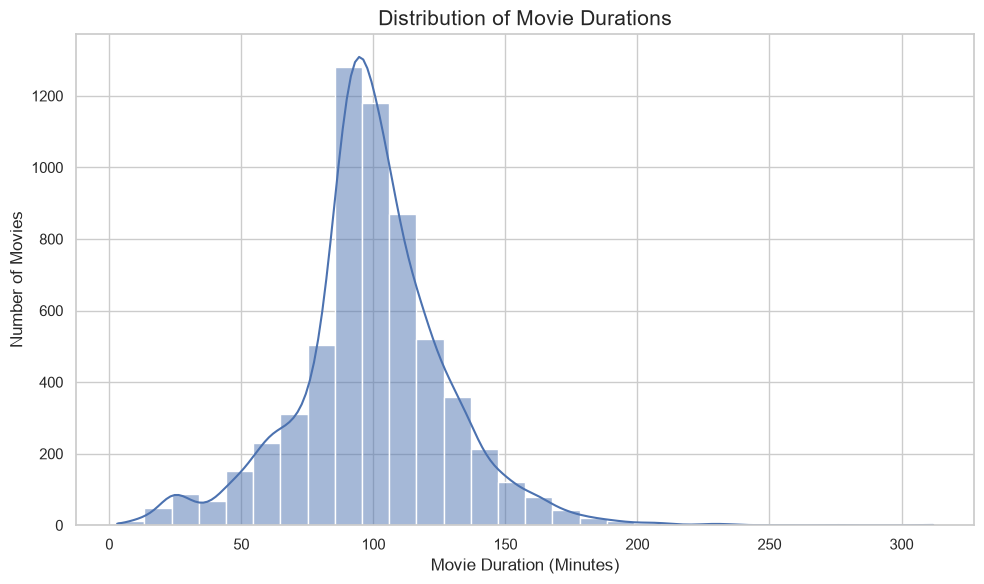

In [14]:
# Keep records with valid movie duration values
valid_movies = movies.dropna(subset=["duration_minutes"]).copy()

# Create the histogram
plt.figure(figsize=(10, 6))

sns.histplot(
    data=valid_movies,
    x="duration_minutes",
    bins=30,
    kde=True
)

plt.title("Distribution of Movie Durations", fontsize=15)
plt.xlabel("Movie Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.tight_layout()

plt.savefig(
    output_dir / "06_movie_duration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
# Calculate the proportion of each content type
content_percentages = (
    data["type"].value_counts(normalize=True) * 100
)

print("Content Type Percentages:")
print(content_percentages.round(2))

# Find the year with the highest recorded additions
if data["year_added"].notna().any():
    yearly_additions = data["year_added"].value_counts().sort_index()

    print(
        "\nYear with the highest recorded additions:",
        yearly_additions.idxmax()
    )

    print(
        "Number of titles added in that year:",
        yearly_additions.max()
    )

# Summarize movie duration
print("\nMovie Duration Summary:")
display(valid_movies["duration_minutes"].describe())

# Show the most frequently listed genres
print("\nTop 5 Genres:")
display(genre_counts.head(5))

# Show the most frequently associated countries
print("\nTop 5 Countries:")
display(country_counts.head(5))

Content Type Percentages:
type
Movie      69.62
TV Show    30.38
Name: proportion, dtype: Float64

Year with the highest recorded additions: 2019.0
Number of titles added in that year: 2016

Movie Duration Summary:


count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_minutes, dtype: float64


Top 5 Genres:


listed_in
International Movies      2752
Dramas                    2427
Comedies                  1674
International TV Shows    1351
Documentaries              869
Name: count, dtype: int64


Top 5 Countries:


country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Name: count, dtype: int64